In [1]:
# ================================
# STEP 1: Import Libraries
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

In [2]:
# ================================
# STEP 2: Load Dataset
# ================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
# ================================
# STEP 3: Data Inspection
# ================================
print(df.shape)
print(df.isnull().sum())
print(df.describe())

(20640, 9)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.0

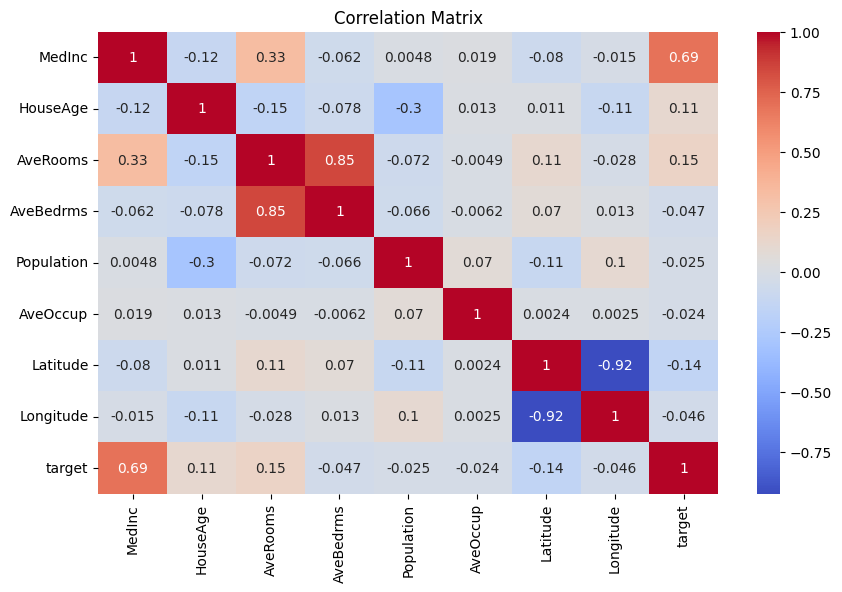

In [4]:
# ================================
# STEP 4: EDA (Visualization)
# ================================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [5]:

# ================================
# STEP 5: Feature & Target
# ================================
X = df.drop('target', axis=1)
y = df['target']

In [6]:
# ================================
# STEP 6: Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# ================================
# STEP 7: Baseline Model (Linear Regression)
# ================================
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [8]:
# ================================
# STEP 8: Evaluation Function
# ================================
def evaluate(y_test, y_pred, name):
    print(f"\n{name} Performance:")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

evaluate(y_test, y_pred_lr, "Linear Regression")


Linear Regression Performance:
R2 Score: 0.5757877060324508
MAE: 0.5332001304956553
MSE: 0.5558915986952444
RMSE: 0.7455813830127764


In [9]:
# ================================
# STEP 9: Feature Scaling
# ================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = lr_scaled.predict(X_test_scaled)

evaluate(y_test, y_pred_scaled, "Scaled Linear Regression")


Scaled Linear Regression Performance:
R2 Score: 0.575787706032451
MAE: 0.5332001304956565
MSE: 0.5558915986952442
RMSE: 0.7455813830127763


In [10]:

# ================================
# STEP 10: Additional Models
# ================================
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
evaluate(y_test, y_pred_dt, "Decision Tree")

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate(y_test, y_pred_rf, "Random Forest")


Decision Tree Performance:
R2 Score: 0.622075845135081
MAE: 0.45467918846899225
MSE: 0.495235205629094
RMSE: 0.7037294974840077

Random Forest Performance:
R2 Score: 0.8051230593157366
MAE: 0.32754256845930246
MSE: 0.2553684927247781
RMSE: 0.5053399773665033


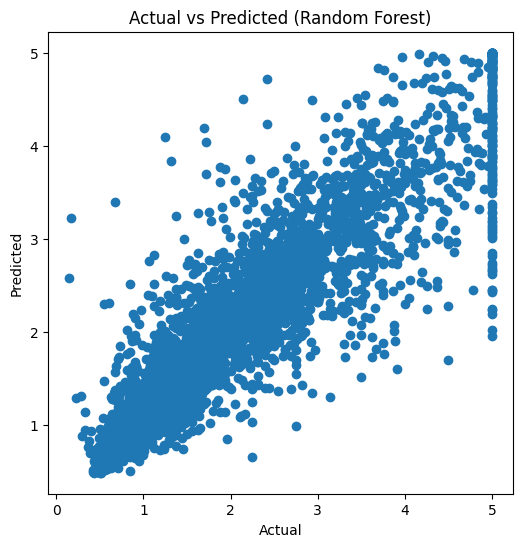

In [11]:
# ================================
# STEP 11: Visualization (Actual vs Predicted)
# ================================
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [12]:
# ================================
# STEP 12: Overfitting Check
# ================================
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print("\nOverfitting Check:")
print("Train Score:", train_score)
print("Test Score:", test_score)


Overfitting Check:
Train Score: 0.9735726320302575
Test Score: 0.8051230593157366


In [13]:
# ================================
# STEP 13: Hyperparameter Tuning
# ================================
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("\nBest Parameters:", grid.best_params_)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)
evaluate(y_test, y_pred_best, "Tuned Random Forest")


Best Parameters: {'max_depth': None, 'n_estimators': 100}

Tuned Random Forest Performance:
R2 Score: 0.8058101009128545
MAE: 0.32728151061046523
MSE: 0.25446818724748965
RMSE: 0.5044483989938809


In [14]:
# ================================
# STEP 14: Save Model
# ================================
joblib.dump(best_model, "house_price_model.pkl")

print("\nModel Saved Successfully!")


Model Saved Successfully!
